In [25]:
import numpy as np
import os, glob

import matplotlib.pyplot as plt

from PIL import Image

from scipy.stats import ttest_ind

# ..........torch imports............
import torch
import torchvision

from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms

#.... Captum imports..................
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients

from captum.concept import TCAV
from captum.concept import Concept

from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str

In [26]:
# Define de transforms to be applied to InceptionV3
# https://github.com/pytorch/hub/blob/master/pytorch_vision_inception_v3.md#:~:text=All%20pre%2Dtrained,0.224%2C%200.225%5D.
def transform(img):
    transform = transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return transform(img)

In [27]:
def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("RGB")
    return transform(img)

def load_image_tensors(class_name, root_path='data/tcav/image/imagenet/', transform=True):
    path = os.path.join(root_path, class_name)
    filenames = glob.glob(path + '/*.jpg')

    tensors = []
    for filename in filenames:
        img = Image.open(filename).convert('RGB')
        tensors.append(transform(img) if transform else img)
    
    return tensors

def assemble_concept(name, id, concepts_path="data/tcav/image/concepts/"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)

    return Concept(id=id, name=name, data_iter=concept_iter)

In [28]:
model = torchvision.models.googlenet(pretrained=True)
model = model.eval()

/opt/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


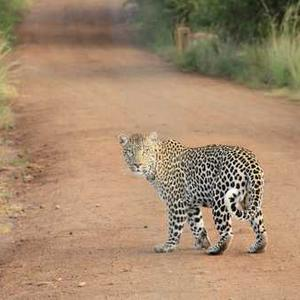

In [29]:
img = Image.open("data/example_images/jag.jpg").convert("RGB")
img


In [30]:
# Just to test it actually predicts correctly the output, we see that Nautilus is class 117 which is the expected output
x_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    output = model(x_tensor)

class_predicted = torch.argmax(output, dim=1).item()

print("Predicted class index:", class_predicted)


Predicted class index: 288


In [31]:
concepts_path = "data/concepts/"

stripped_concept = assemble_concept("stripped", 0, concepts_path=concepts_path)
spiralled_concept = assemble_concept("spiralled", 1, concepts_path=concepts_path)
freckled_concept = assemble_concept("frekeled", 2, concepts_path=concepts_path)
braided_concept = assemble_concept("braided", 3, concepts_path=concepts_path)
chequered_concept = assemble_concept("chequered", 4, concepts_path=concepts_path)
random_0_concept = assemble_concept("random_0", 5, concepts_path=concepts_path)
random_1_concept = assemble_concept("random_1", 6, concepts_path=concepts_path)
dotted_concept = assemble_concept("dotted", 7, concepts_path=concepts_path)


concepts = [
    stripped_concept,
    spiralled_concept,
    freckled_concept,
    braided_concept,
    chequered_concept,
    random_0_concept,
    random_1_concept,
    dotted_concept
]


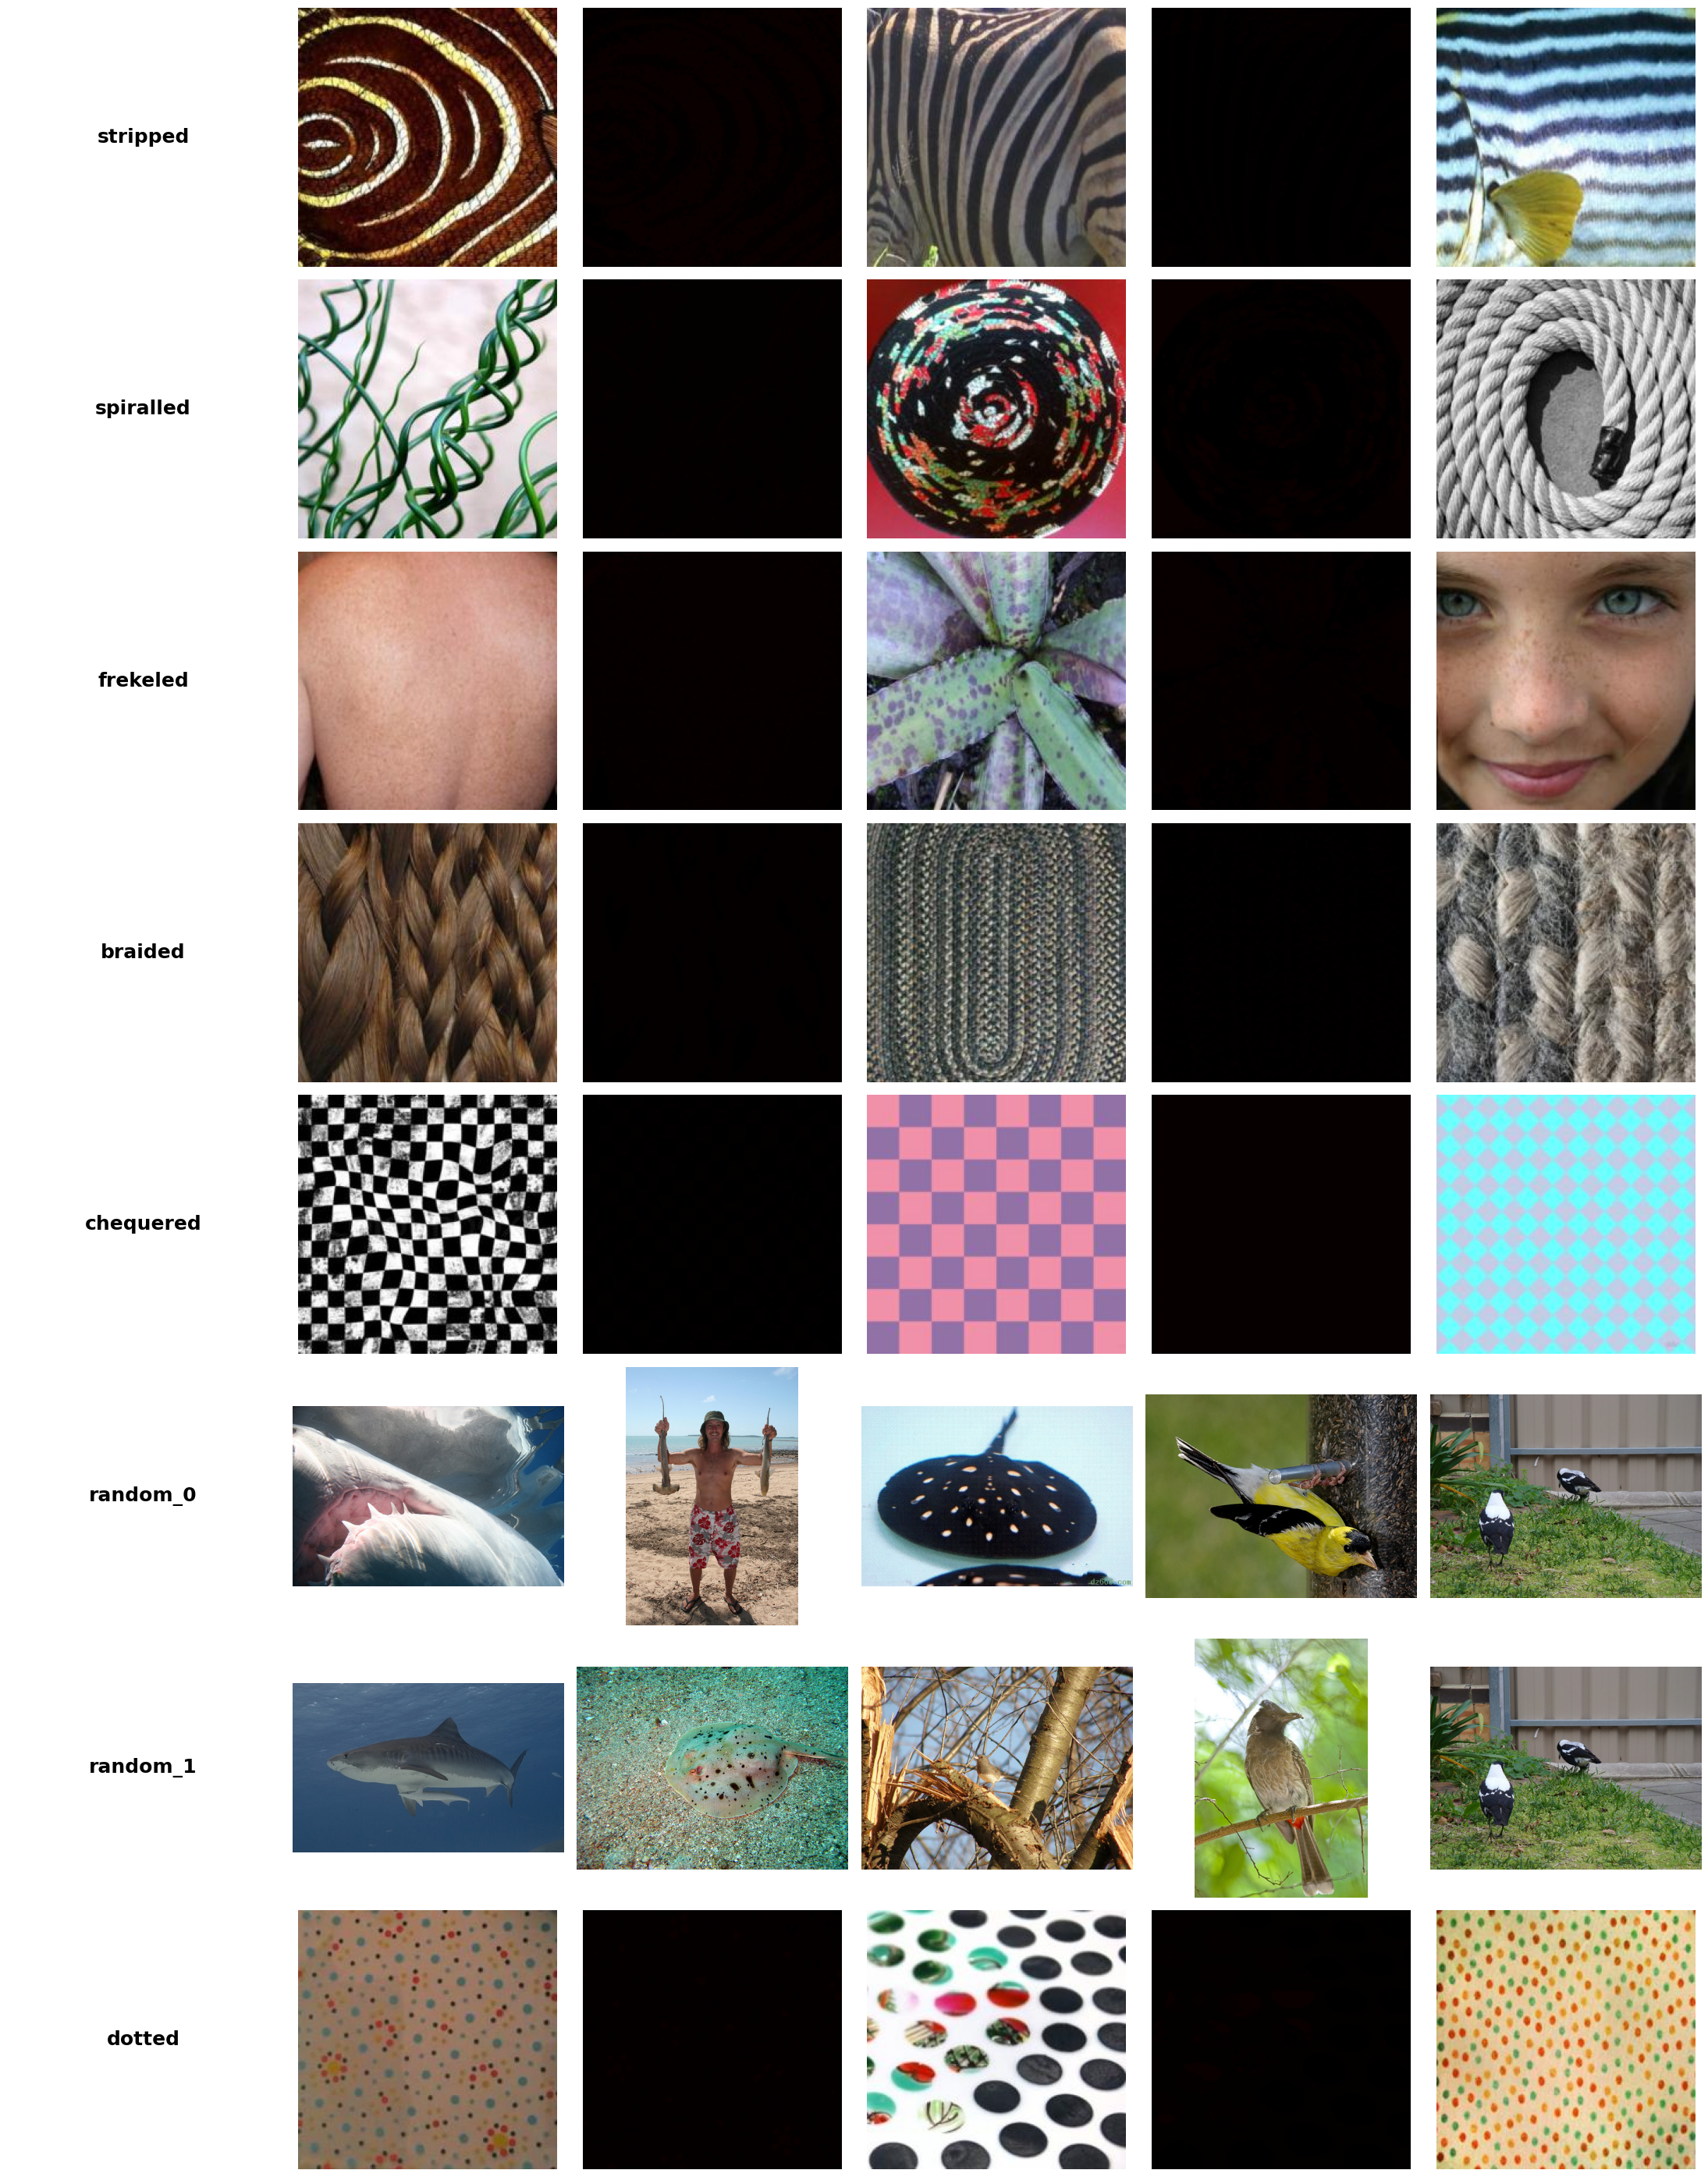

In [32]:
n_figs = 5 
n_concepts = len(concepts)

fig, axs = plt.subplots(
    n_concepts, n_figs + 1,
    figsize=(22, 3.5 * n_concepts)
)

if n_concepts == 1:
    axs = [axs]


for c, concept in enumerate(concepts):
    concept_path = os.path.join(concepts_path, concept.name)
    img_files = sorted(glob.glob(os.path.join(concept_path, '*')))
    
    for i in range(n_figs + 1):
        ax = axs[c][i] if n_concepts > 1 else axs[i]
        ax.axis('off')
        
        if i == 0:
            
            ax.text(
                0.5, 0.5, concept.name,
                ha='center', va='center',
                fontsize=18, weight='bold'
            )
        else:
            if i-1 < len(img_files):
                img = plt.imread(img_files[i-1])
                ax.imshow(img)
            else:
                ax.set_facecolor('lightgray')
                ax.text(0.5, 0.5, "No image", ha='center', va='center')


plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [33]:
layers=['inception4c', 'inception4d', 'inception4e']

mytcav = TCAV(model=model,
              layers=layers,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))

/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


In [34]:
# We define a set for testing
experimental_set_rand = [[dotted_concept, random_0_concept], [dotted_concept, random_1_concept]]

In [35]:
leop_id = 289

tcav_scores_w_random = mytcav.interpret(inputs=x_tensor,
                                        experimental_sets=experimental_set_rand,
                                        target=leop_id,
                                        n_steps=5,
                                       )
tcav_scores_w_random

defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'7-5': defaultdict(None,
                         {'inception4c': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.5459,  0.5459])},
                          'inception4d': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.1769,  0.1769])},
                          'inception4e': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.3720,  0.3720])}}),
             '7-6': defaultdict(None,
                         {'inception4c': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.3622,  0.3622])},
                          'inception4d': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-0.1416,  0.1416])},
                          'inception4e': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([

In [36]:
def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores):
    fig, ax = plt.subplots(1, len(experimental_sets), figsize = (25, 7))

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):

        concepts = experimental_sets[idx_es]
        concepts_key = concepts_to_str(concepts)

        pos = [np.arange(len(layers))]
        for i in range(1, len(concepts)):
            pos.append([(x + barWidth) for x in pos[i-1]])
        _ax = (ax[idx_es] if len(experimental_sets) > 1 else ax)
        for i in range(len(concepts)):
            val = [format_float(scores['sign_count'][i]) for layer, scores in tcav_scores[concepts_key].items()]
            _ax.bar(pos[i], val, width=barWidth, edgecolor='white', label=concepts[i].name)

        
        _ax.set_xlabel('Set {}'.format(str(idx_es)), fontweight='bold', fontsize=16)
        _ax.set_xticks([r + 0.3 * barWidth for r in range(len(layers))])
        _ax.set_xticklabels(layers, fontsize=16)

        
        _ax.legend(fontsize=16)

    plt.show()

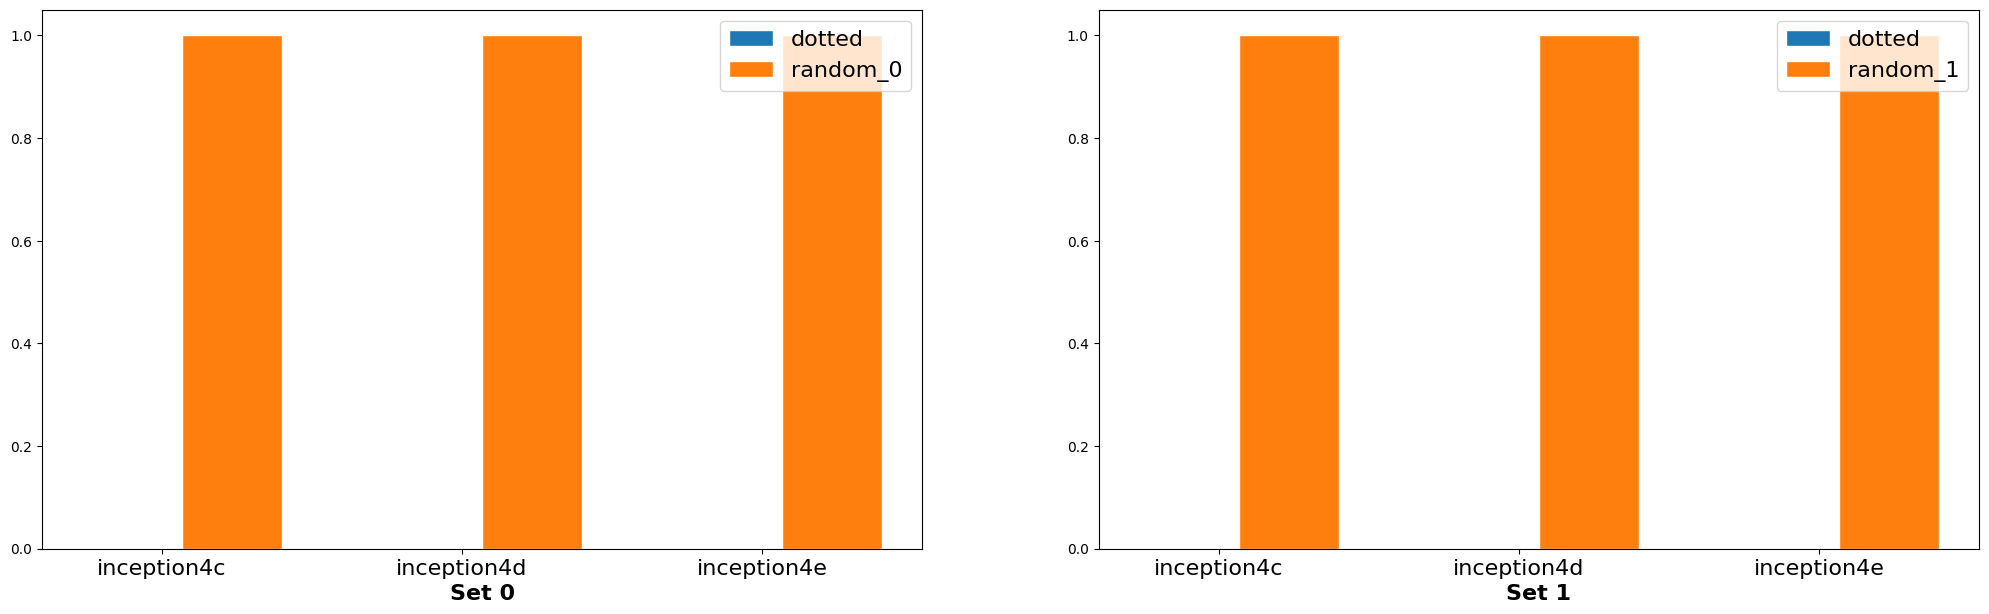

In [37]:
plot_tcav_scores(experimental_set_rand, tcav_scores_w_random)